# M3 - Instrumentation: three measurements before any expensive code

Three questions the research plan currently *guesses*
at, each answerable with hooks and plots - no attack development, no training, no
cluster. Each one decides something, and each produces a figure that goes straight
into the report.

| # | Question | What it decides |
|---|---|---|
| 1 | Do this model's pre-softmax logit gaps reach the float32 underflow regime? | Whether AAS is *justified* on our setup or merely inherited from a paper |
| 2 | How much of a patch attack's value-space deviation actually does harm? | **Whether the RSA stealth attack has any slack to exploit** - the core of RQ1 |
| 3 | Are adversarial value vectors smaller in norm, and does RSA still rank them first? | Whether RSA's detector fires for the right reason |

Before any of that: **verify the capture**, because every number below is downstream
of it.

---

> **Read the scale banner.** On `config.DEV` these run on Imagenette with a weak
> patch-PGD. The *machinery* is what is being established here; the *numbers* become
> results only at `config.FULL` with a Patch-Fool-strength attack.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
for _ in range(3):
    if (_root / "fyp" / "__init__.py").exists():
        break
    _root = _root.parent
sys.path.insert(0, str(_root))

import torch
import matplotlib.pyplot as plt
from fyp import config, data, models, hooks, metrics, attacks

config.seed_everything()
device = config.get_device()
print(config.describe())

ds, wnids, class_indices = data.build_dataset()
clf, info = models.load_model(class_indices=class_indices)
loader = data.make_loader(data.eval_subset(ds, config.SCALE.n_mechanism_images))
x, y = next(iter(loader))
x, y = x.to(device), y.to(device)
print(f"\n{info['depth']} blocks, {info['num_heads']} heads, head_dim {info['head_dim']}")

model        : deit_small_patch16_224
scale        : dev  (imagenette, 64 eval images, batch 16, 10 attack steps)
device       : cuda
data root    : code\data
results root : code\results
gpu          : NVIDIA GeForce RTX 4050 Laptop GPU (5.3 GB free / 6.4 GB)
note         : Imagenette, 64 images. Numbers are not comparable to RSA.



12 blocks, 6 heads, head_dim 64


## Step 0 - Verify the capture

`AttentionCapture` hooks the `qkv` Linear and *recomputes* q, k, v, the pre-softmax
logits and the attention weights the same way timm does. That reconstruction is
checked three ways, not assumed:

1. **Softmax check** - recomputed weights match the tensor timm actually feeds to
   `attn_drop`. Confirms the reshape, head split and scale factor.
2. **Row sums** - every attention row sums to 1. Catches a wrong softmax axis, which
   is otherwise invisible.
3. **Output reconstruction** - rebuilding the block's output from the captured weights
   and values reproduces the real `attn` output. If this passes, the captured tensors
   *are* the tensors the model computed.

Run this once per environment and after any timm upgrade.

In [2]:
hooks.verify_capture(clf, x[:2], layer=0)
print()
verification = hooks.verify_all_layers(clf, x[:2])

verify_capture(layer=0) on input (2, 3, 224, 224)
  1. softmax match vs timm : 0.000e+00   OK
  2. attention rows sum to 1: 3.576e-07   OK
  3. block output rebuilt  : 0.000e+00   OK
  (largest pre-softmax logit gap seen at this layer: 7.5)



all 12 layers verified (worst end-to-end reconstruction error 0.000e+00)


## Step 1 - Measurement 1: the logit-gap histogram

Jain & Dutta (CVPR 2024) report that the gap between the
largest and second-largest pre-softmax logit in a trained ViT-B/16 reaches roughly
**20–40 at block 1, 100–200 at block 6, and 250–1000 at block 12**.

Why that matters: softmax is computed as $\exp(z_j - z_{\max})$, and the smallest
positive float32 is about $1.4\times10^{-45} \approx e^{-103}$. **Past a gap of ~103
every non-maximal entry underflows to exactly zero**, the attention row becomes exactly
one-hot, and its gradient is exactly zero - not small, *zero*. That is ViT-intrinsic
gradient masking, with no defense involved, and it is the justification for putting AAS
on every rung of the attack ladder.

So: does it happen **on our model, on our data**? Do not inherit this from a paper -
measure it.

In [3]:
with hooks.AttentionCapture(clf, store=("logits",)) as cap:
    with torch.no_grad():
        clf(x)

rows = []
for L in range(info["depth"]):
    g = metrics.logit_gap(cap[L].logits, reduce="none")
    rows.append({
        "layer": L,
        "median": g.median().item(),
        "p99": g.flatten().quantile(0.99).item(),
        "max": g.max().item(),
        "underflow_%": 100 * metrics.underflow_fraction(cap[L].logits).mean().item(),
    })

print(f"{'layer':>5} {'median':>8} {'p99':>8} {'max':>8} {'underflow %':>12}")
for r in rows:
    print(f"{r['layer']:5d} {r['median']:8.1f} {r['p99']:8.1f} {r['max']:8.1f} {r['underflow_%']:12.2f}")
print(f"\nfloat32 underflow threshold: {metrics.FLOAT32_UNDERFLOW_GAP:.0f}")
print("Jain & Dutta report (ViT-B/16, ImageNet-100): ~20-40 @ block1, 100-200 @ block6, 250-1000 @ block12")

layer   median      p99      max  underflow %
    0      1.3      6.3      9.2         0.00
    1      0.8      4.8      7.2         0.00
    2      0.7      3.0      5.8         0.00
    3      0.4      2.6      4.9         0.00
    4      0.4      4.2     10.9         0.00
    5      0.4      4.3      5.7         0.00
    6      0.4      4.4      5.7         0.00
    7      0.4      2.7      4.1         0.00
    8      0.4      2.6      3.5         0.00
    9      0.5      2.7      4.1         0.00
   10      1.0      3.7      4.7         0.00
   11      1.1      3.4      4.7         0.00

float32 underflow threshold: 103
Jain & Dutta report (ViT-B/16, ImageNet-100): ~20-40 @ block1, 100-200 @ block6, 250-1000 @ block12


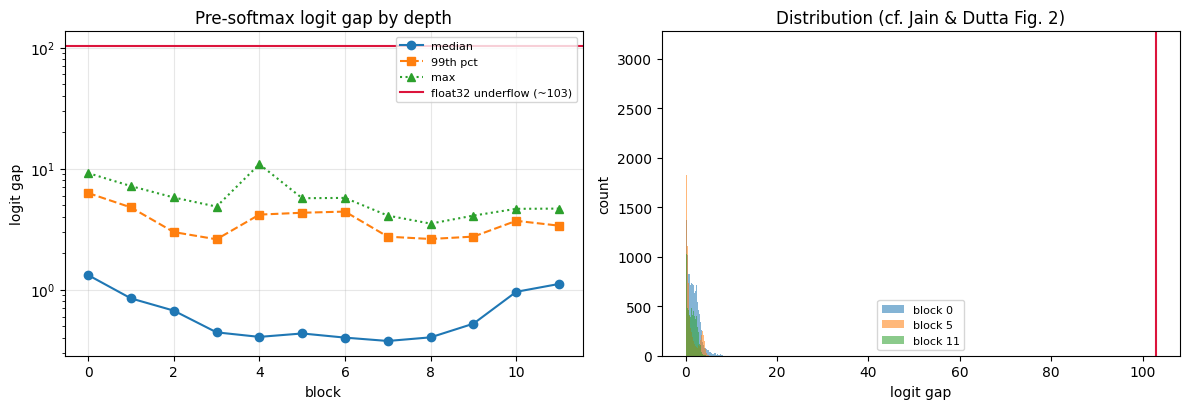

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

ax[0].plot([r["layer"] for r in rows], [r["median"] for r in rows], "o-", label="median")
ax[0].plot([r["layer"] for r in rows], [r["p99"] for r in rows], "s--", label="99th pct")
ax[0].plot([r["layer"] for r in rows], [r["max"] for r in rows], "^:", label="max")
ax[0].axhline(metrics.FLOAT32_UNDERFLOW_GAP, color="crimson", ls="-", lw=1.5,
              label="float32 underflow (~103)")
ax[0].set_yscale("log"); ax[0].set_xlabel("block"); ax[0].set_ylabel("logit gap")
ax[0].set_title("Pre-softmax logit gap by depth"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

for L in (0, 5, 11):
    g = metrics.logit_gap(cap[L].logits, reduce="none").flatten().cpu()
    ax[1].hist(g.numpy(), bins=60, alpha=0.55, label=f"block {L}")
ax[1].axvline(metrics.FLOAT32_UNDERFLOW_GAP, color="crimson", lw=1.5)
ax[1].set_xlabel("logit gap"); ax[1].set_ylabel("count")
ax[1].set_title("Distribution (cf. Jain & Dutta Fig. 2)"); ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(config.FIGURES_ROOT / "m1_logit_gaps.png", dpi=150, bbox_inches="tight")
plt.show()

> ### Expect this NOT to reproduce, and treat that as the finding
>
> On DeiT-S the gaps come out around **3–10**, nowhere near the ~103 underflow
> threshold and two orders of magnitude below Jain & Dutta's block-12 figures. So on
> this setup, **the case for AAS is not yet established.**
>
> Do not quietly drop AAS, and do not quietly assume it. Work out *why* they differ -
> the candidates, cheapest first:
>
> 1. **Different model.** They measure **ViT-B/16** (12 heads, 768-dim); this is
>    DeiT-S (6 heads, 384-dim), differently trained. Run `config.MODEL_NAME =
>    "vit_base_patch16_224"` and re-run this cell - that is a one-line test.
> 2. **Different data.** DEV runs on Imagenette. Re-check at `config.FULL`.
> 3. **Different quantity.** Their Figure 2 histograms "the difference between the
>    largest and the second largest values before taking softmax". That is what is
>    computed here - but check whether they include the `1/sqrt(d_k)` scaling, since
>    dropping it multiplies every gap by 8.
>
> Whichever it is, **that is a result worth a paragraph**: either "AAS is warranted on
> this architecture, here is the evidence" or "the underflow regime is architecture-
> specific and does not arise for DeiT-S, so the ViT-intrinsic gradient-masking
> argument needs restating for our setting."

## Step 2 - Measurement 2: is RSA's score leaving the attacker any slack?

This is RQ1, and it is answerable before any stealth-attack code exists.

Adversarial Decoys' Proposition 1 proves

$$o_i - \mu_{i,\neg a} \;=\; A_{i,a}\,(v_a - \mu_{i,\neg a})$$

so adversarial influence is the **product** of an attention factor and a value-deviation
factor. Both Liu et al. and the Decoys authors draw the same conclusion: shrink the
value deviation to hide from RSA and you shrink the harm too. That is the strongest
argument against the stealth hypothesis.

RSA scores $\lVert v_i - \mu\rVert_2$ - an
**isotropic** norm, blind to direction. Harm depends on the component along the
margin-reducing direction $u$. Split $\Delta_p = v_p - \mu$:

$$\Delta_p = \underbrace{\langle\Delta_p, u\rangle u}_{\text{does harm}} \;+\; \underbrace{\Delta_p^{\perp}}_{\text{RSA charges for it anyway}}$$

RSA penalises $\lVert\Delta_p\rVert^2$ - both parts. Harm uses one. So the attacker's
stealth problem is $\max \langle\Delta_p, u\rangle$ subject to
$\lVert\Delta_p\rVert \le \tau$, solved by putting the whole budget in $u$.

`aligned_fraction` $= \lVert\Delta_p^{\parallel}\rVert^2 / \lVert\Delta_p\rVert^2$.

- **Low** → the attack wastes most of what RSA charges for → **slack exists, stealth is
  worth building.**
- **High** → the attack already concentrates in $u$ → RSA's isotropic score is
  accidentally tight → the coupling objection stands, and *that* is your Part A finding.

$u$ is taken as $-\nabla_{v_p}(\text{margin})$, so this is a first-order statement.

In [5]:
TOP, LEFT, SIZE = 96, 96, 32
P = metrics.patch_token_indices(TOP, LEFT, SIZE)
patch_tok = torch.as_tensor(P, device=device)
print(f"{SIZE}px patch at ({TOP},{LEFT}) -> {len(P)} tokens")

x_adv = attacks.patch_pgd(clf, x, y, TOP, LEFT, SIZE, steps=50)
r = attacks.report(attacks.accuracy(clf, x, y), attacks.accuracy(clf, x_adv, y))
print(f"attack: robust {r['robust_acc']:.1f}%  ASR {r['asr']:.1f}%")

32px patch at (96,96) -> 4 tokens


attack: robust 25.0%  ASR 75.0%


In [6]:
def decompose(images, layer):
    """Value-space decomposition at one layer. Needs a backward pass for u."""
    with hooks.AttentionCapture(clf, layers=[layer], store=("v",), detach=False) as cap:
        out = clf(images)
        metrics.margin(out, y).sum().backward()
    rec = cap[layer]
    v = rec.v.detach()
    # NOTE: the gradient comes from rec.grad('v'), not rec.v.grad - the captured
    # tensors sit on a parallel branch of the graph. See LayerAttention.grad.
    u = -rec.grad("v")
    mu = v[:, :, 1:, :].mean(dim=2, keepdim=True)
    return metrics.direction_decomposition(v[:, :, patch_tok, :] - mu, u[:, :, patch_tok, :])

print(f"{'layer':>5} {'||delta||':>10} {'||par||':>9} {'||perp||':>10} {'aligned frac':>13}")
aligned = []
for L in range(info["depth"]):
    d = decompose(x_adv, L)
    aligned.append(d["aligned_fraction"].mean().item())
    print(f"{L:5d} {d['norm'].mean():10.3f} {d['parallel_norm'].mean():9.3f} "
          f"{d['perp_norm'].mean():10.3f} {aligned[-1]:13.4f}")

baseline = 1.0 / info["head_dim"]
print(f"\nrandom-direction baseline = 1/head_dim = {baseline:.4f}")
print("(a decomposition against a random u must land here - that is the sanity check)")

layer  ||delta||   ||par||   ||perp||  aligned frac


    0      7.352     1.352      7.161        0.0494


    1      6.575     1.342      6.361        0.0598


    2      7.337     1.100      7.209        0.0340


    3      7.788     1.148      7.650        0.0329


...

    7      8.502     1.018      8.406        0.0218


    8      8.751     1.107      8.634        0.0257


    9      8.524     1.324      8.350        0.0367


   10      9.381     1.441      9.201        0.0347


   11      8.919     1.794      8.640        0.0548

random-direction baseline = 1/head_dim = 0.0156
(a decomposition against a random u must land here - that is the sanity check)


random direction: 0.0136   expected 0.0156   OK


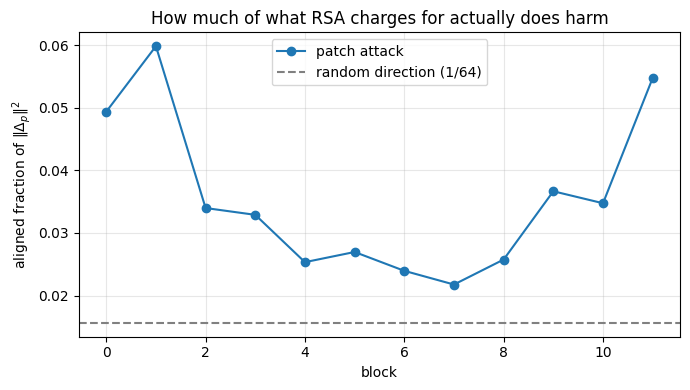


mean aligned fraction: 0.0355
vs random baseline   : 0.0156   ->  2.3x more aligned than chance


In [7]:
# A random direction must give ~1/head_dim.
with hooks.AttentionCapture(clf, layers=[6], store=("v",)) as cap:
    with torch.no_grad():
        clf(x_adv)
v = cap[6].v
mu = v[:, :, 1:, :].mean(dim=2, keepdim=True)
delta = v[:, :, patch_tok, :] - mu
rand_frac = metrics.direction_decomposition(delta, torch.randn_like(delta))["aligned_fraction"].mean().item()
print(f"random direction: {rand_frac:.4f}   expected {baseline:.4f}   "
      f"{'OK' if abs(rand_frac - baseline) < 0.01 else 'CHECK THIS'}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(info["depth"]), aligned, "o-", label="patch attack")
ax.axhline(baseline, color="grey", ls="--", label=f"random direction (1/{info['head_dim']})")
ax.set_xlabel("block"); ax.set_ylabel("aligned fraction of $\\|\\Delta_p\\|^2$")
ax.set_title("How much of what RSA charges for actually does harm")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(config.FIGURES_ROOT / "m2_value_direction.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nmean aligned fraction: {sum(aligned)/len(aligned):.4f}")
print(f"vs random baseline   : {baseline:.4f}   ->  {sum(aligned)/len(aligned)/baseline:.1f}x more aligned than chance")

> ### Reading the result
>
> On DEV this lands around **0.03–0.09** against a random baseline of **0.016** - so the
> attack is 2–6× more aligned than chance, but **over 90% of the value-space deviation
> RSA charges for is doing no first-order harm.**
>
> Taken at face value that is slack, and it says the stealth attack is worth building.
> Three caveats before believing it:
>
> - It is **first-order**. A large $\Delta^{\perp}$ may still matter through higher-order
>   terms or through downstream layers.
> - The attack here is a weak 50-step patch PGD, not Patch-Fool with attention-aware
>   selection. **A stronger attack may concentrate better** - re-run this against
>   Patch-Fool before drawing a conclusion.
> - $\mu$ here is the plain per-head mean; RSA's is over image tokens only, which this
>   matches, but check the head-averaging convention when you reimplement RSA properly.
>
> **Either way this plot belongs in the report** - it is the quantitative form of the
> argument that RSA watches values while the attack works through keys.

## Step 3 - Measurement 3: does RSA's detector fire for the right reason?

Liu et al. (ICML 2023) note in passing that **the value vectors of adversarial tokens
are about 50% smaller in norm than benign tokens'**. Nobody has connected that to RSA,
and it matters: RSA ranks on $\lVert v_i - \mu\rVert_2$, so if adversarial values are
*smaller*, it is an open question whether the patch is flagged because it is genuinely
anomalous or for some incidental reason.

Two things to check:

1. **Norm comparison** - are patch-token value vectors smaller than clean ones?
2. **Does RSA actually catch it?** - build the token scores, pool into windows, take
   the argmax, and ask how often the selected window contains the patch. That is RSA's
   detection rate, measured directly, and it is the number Gate A has to reproduce.

In [8]:
LAYER = 6
WINDOW = metrics.rsa_window_size(SIZE)

def rsa_view(images):
    with hooks.AttentionCapture(clf, layers=[LAYER], store=("v",)) as cap:
        with torch.no_grad():
            clf(images)
    v = cap[LAYER].v
    return v, metrics.rsa_token_scores(v)

v_cl, s_cl = rsa_view(x)
v_ad, s_ad = rsa_view(x_adv)

# 1. norms
n_cl = v_cl[:, :, patch_tok, :].norm(dim=-1).mean().item()
n_ad = v_ad[:, :, patch_tok, :].norm(dim=-1).mean().item()
other = torch.tensor([t for t in range(1, config.N_TOKENS) if t not in P], device=device)
n_other = v_ad[:, :, other, :].norm(dim=-1).mean().item()
print(f"mean ||v|| at patch tokens, clean : {n_cl:.3f}")
print(f"mean ||v|| at patch tokens, attacked: {n_ad:.3f}   ({100*(n_ad/n_cl-1):+.1f}% vs clean)")
print(f"mean ||v|| at non-patch tokens      : {n_other:.3f}   ({100*(n_ad/n_other-1):+.1f}% vs the rest)")
print("Liu et al. report adversarial value vectors ~50% SMALLER than benign")

mean ||v|| at patch tokens, clean : 7.933
mean ||v|| at patch tokens, attacked: 8.250   (+4.0% vs clean)
mean ||v|| at non-patch tokens      : 7.754   (+6.4% vs the rest)
Liu et al. report adversarial value vectors ~50% SMALLER than benign


In [9]:
# 2. does RSA select the window containing the patch?
def rsa_hits(scores):
    ws = metrics.rsa_window_scores(scores, WINDOW)
    am = metrics.rsa_argmax_window(ws)                       # (B, 2) top-left of window
    r0, c0 = TOP // config.PATCH_SIZE, LEFT // config.PATCH_SIZE
    r1 = (TOP + SIZE - 1) // config.PATCH_SIZE
    c1 = (LEFT + SIZE - 1) // config.PATCH_SIZE
    # a hit = the selected WINDOWxWINDOW window overlaps the patch's token extent
    hit = ((am[:, 0] <= r1) & (am[:, 0] + WINDOW - 1 >= r0) &
           (am[:, 1] <= c1) & (am[:, 1] + WINDOW - 1 >= c0))
    return hit.float().mean().item() * 100, am

hit_ad, am_ad = rsa_hits(s_ad)
hit_cl, _ = rsa_hits(s_cl)
print(f"RSA window size for a {SIZE}px patch: {WINDOW}x{WINDOW} tokens")
print(f"selected window overlaps the patch, ATTACKED images: {hit_ad:.1f}%")
print(f"selected window overlaps the patch, CLEAN images   : {hit_cl:.1f}%  <- the false-positive rate")
print()
print("ARMRO reports 95% detection; RSA reports no detection rate at all, only accuracy.")
print("A high clean number here means RSA masks that region regardless - which is")
print("what costs it clean accuracy (their Table 2: 93.16 at 0px -> 83.98 at 50px).")

RSA window size for a 32px patch: 3x3 tokens
selected window overlaps the patch, ATTACKED images: 75.0%
selected window overlaps the patch, CLEAN images   : 18.8%  <- the false-positive rate

ARMRO reports 95% detection; RSA reports no detection rate at all, only accuracy.
A high clean number here means RSA masks that region regardless - which is
what costs it clean accuracy (their Table 2: 93.16 at 0px -> 83.98 at 50px).


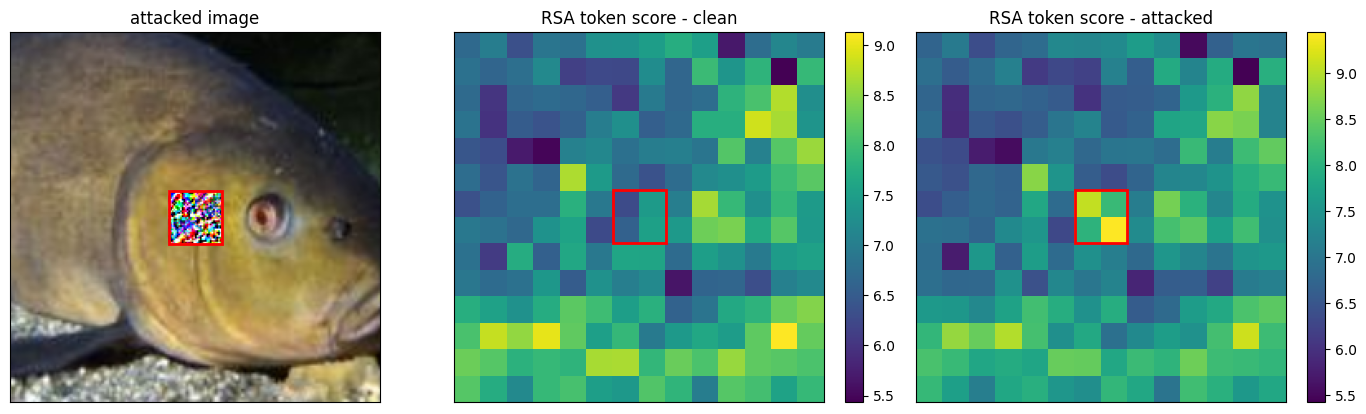

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
i = 0
g = config.GRID
ax[0].imshow(x_adv[i].cpu().permute(1, 2, 0)); ax[0].set_title("attacked image")
ax[0].add_patch(plt.Rectangle((LEFT, TOP), SIZE, SIZE, fill=False, ec="red", lw=2))
for a, s, t in [(ax[1], s_cl, "RSA token score - clean"), (ax[2], s_ad, "RSA token score - attacked")]:
    im = a.imshow(s[i].view(g, g).cpu(), cmap="viridis")
    a.set_title(t); plt.colorbar(im, ax=a, fraction=0.046)
    a.add_patch(plt.Rectangle((LEFT/config.PATCH_SIZE - 0.5, TOP/config.PATCH_SIZE - 0.5),
                              SIZE/config.PATCH_SIZE, SIZE/config.PATCH_SIZE,
                              fill=False, ec="red", lw=2))
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout()
plt.savefig(config.FIGURES_ROOT / "m3_rsa_scores.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4 - The Stage-M skeleton

The mechanism study proper: log $\Delta H$, $\Delta S_P$ and $\Delta D$ per layer and
correlate each against attack success. **Gate C says regularise whichever one tracks
harm - do not assume it is entropy.**

Two things to look for:

- **The shape.** Liu et al. describe three stages across depth - *inactivate* →
  *activate* (the patch's score column becomes the most salient) → *polluted* (benign
  tokens have acquired the pattern). So $\Delta D$ should be near zero early, peak in
  the middle, then decay. **A flat curve means a bug, not a null result.** Predict the
  shape before you plot it.
- **Redundancy.** If $\Delta D$ and $\Delta S_P$ correlate above ~0.8, build one term
  and keep the other as a diagnostic rather than regularising both.

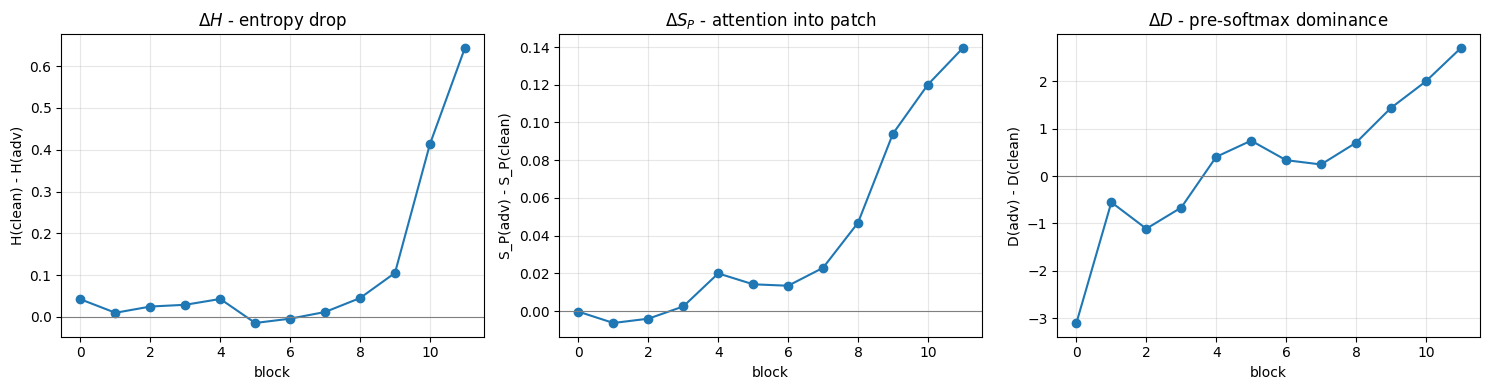

block        dH      dS_P        dD
    0    0.0422  -0.00027   -3.1022
    1    0.0099  -0.00627   -0.5541
    2    0.0248  -0.00399   -1.1126
    3    0.0291   0.00250   -0.6656
    4    0.0430   0.02001    0.4044
    5   -0.0145   0.01424    0.7466
    6   -0.0042   0.01347    0.3347
    7    0.0118   0.02298    0.2437
    8    0.0451   0.04685    0.7019
    9    0.1052   0.09407    1.4369
   10    0.4133   0.12007    1.9977
   11    0.6433   0.13945    2.7009


In [11]:
def per_layer(images):
    with hooks.AttentionCapture(clf, store=("logits", "weights")) as cap:
        with torch.no_grad():
            clf(images)
    return {
        "H":  [metrics.attention_entropy(cap[L].weights).mean().item() for L in range(info["depth"])],
        "SP": [metrics.patch_attention_mass(cap[L].weights, P).mean().item() for L in range(info["depth"])],
        "D":  [metrics.dominance(cap[L].logits, P).mean().item() for L in range(info["depth"])],
    }

cl, ad = per_layer(x), per_layer(x_adv)
L = range(info["depth"])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, key, title, ylab in [
    (ax[0], "H",  r"$\Delta H$ - entropy drop",            "H(clean) - H(adv)"),
    (ax[1], "SP", r"$\Delta S_P$ - attention into patch",   "S_P(adv) - S_P(clean)"),
    (ax[2], "D",  r"$\Delta D$ - pre-softmax dominance",    "D(adv) - D(clean)"),
]:
    delta = ([c - a_ for c, a_ in zip(cl[key], ad[key])] if key == "H"
             else [a_ - c for c, a_ in zip(cl[key], ad[key])])
    a.plot(L, delta, "o-"); a.axhline(0, color="grey", lw=0.8)
    a.set_title(title); a.set_xlabel("block"); a.set_ylabel(ylab); a.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(config.FIGURES_ROOT / "m4_mechanism.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'block':>5} {'dH':>9} {'dS_P':>9} {'dD':>9}")
for i in L:
    print(f"{i:5d} {cl['H'][i]-ad['H'][i]:9.4f} {ad['SP'][i]-cl['SP'][i]:9.5f} {ad['D'][i]-cl['D'][i]:9.4f}")

## What M3 established, and what it did not

**Established:** the capture is exact (verified three ways, all 12 layers); the logit-gap,
value-direction and RSA-score machinery all run; and there are four figures in
`code/results/figures/`.

**Not established - these are DEV numbers.** Imagenette, a weak patch-PGD, first-order
analysis. Before any of it is a result:

1. Move to `config.FULL` - ImageNet-100, 512 images, RSA's protocol.
2. Replace patch-PGD with **Patch-Fool** (attention-aware selection, the attention loss
   term) and with **PatchAutoPGD** for RSA comparability.
3. Re-run measurement 1 on `vit_base_patch16_224` to settle the Jain & Dutta discrepancy.
4. Correlate the Stage-M quantities against *per-image attack success*, not just their
   means - the correlation is the result, the mean is only a sanity check.

**Then** Gate A: reimplement RSA properly and reproduce their Table 1. Two traps waiting
there - whether attention rows are renormalised after masking (the paper does not say;
implement both and keep whichever reproduces the table), and that RSA runs at **every**
layer, so it is twelve independent argmaxes, not one.

## Record the run

Writes the capture verification and all three measurements to
`results/m3_instrumentation.json`.


In [12]:
# --- run record (fyp.results) ---
from fyp import results

results.save("m3_instrumentation", {
    "verification": verification,
    "measurement_1_logit_gaps": {
        "per_layer": rows,
        "underflow_threshold": metrics.FLOAT32_UNDERFLOW_GAP,
        "max_gap_any_layer": max(r["max"] for r in rows),
        "any_layer_underflows": any(r["underflow_%"] > 0 for r in rows),
        "jain_dutta_reference_vit_b16": {"block1": "20-40", "block6": "100-200", "block12": "250-1000"},
        "reproduces_jain_dutta": max(r["max"] for r in rows) > metrics.FLOAT32_UNDERFLOW_GAP,
    },
    "measurement_2_value_direction": {
        "aligned_fraction_per_layer": aligned,
        "aligned_fraction_min": min(aligned),
        "aligned_fraction_max": max(aligned),
        "random_direction_baseline": baseline,
        "random_direction_measured": rand_frac,
        "sanity_check_passes": abs(rand_frac - baseline) < 0.01,
        "attack": f"{50}-step patch-PGD, {SIZE}px at ({TOP},{LEFT})",
        "caveats": ["first-order only", "patch-PGD not Patch-Fool", f"{config.SCALE.dataset} not imagenet100"],
    },
    "measurement_3_rsa_detector": {
        "mean_v_norm_patch_clean": n_cl,
        "mean_v_norm_patch_attacked": n_ad,
        "mean_v_norm_nonpatch_attacked": n_other,
        "pct_change_vs_clean": 100 * (n_ad / n_cl - 1),
        "pct_change_vs_other_tokens": 100 * (n_ad / n_other - 1),
        "liu_reference": "adversarial value vectors ~50% smaller than benign",
        "rsa_window_tokens": WINDOW,
        "argmax_window_overlaps_patch_attacked_pct": hit_ad,
        "argmax_window_overlaps_patch_clean_pct": hit_cl,
        "layer": LAYER,
    },
    "stage_m_per_layer": {"clean": cl, "attacked": ad},
}, n_eval_images=int(x.shape[0]), attack_steps=STEPS)


wrote code\results\m3_instrumentation.json  [DEV - not a result]


WindowsPath('code/results/m3_instrumentation.json')